Training Sparse Mixture of Experts Transformer model...
Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - dense_27_accuracy: 0.4375 - loss: 0.7802
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - dense_27_accuracy: 0.7344 - loss: 0.5646
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - dense_27_accuracy: 0.9219 - loss: 0.4433
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - dense_27_accuracy: 0.9922 - loss: 0.3422
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - dense_27_accuracy: 1.0000 - loss: 0.2512
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - dense_27_accuracy: 1.0000 - loss: 0.1743
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - dense_27_accuracy: 1.0000 - loss: 0.1153
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - dense_27_accuracy: 1.0000 - loss: 0.0836
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - dense_27_accuracy: 1.0000 - loss: 0.0561
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - dense_27_accuracy: 1.0000 - loss: 0.0334
Epoch 11/15
4/4 ━━━━━━━

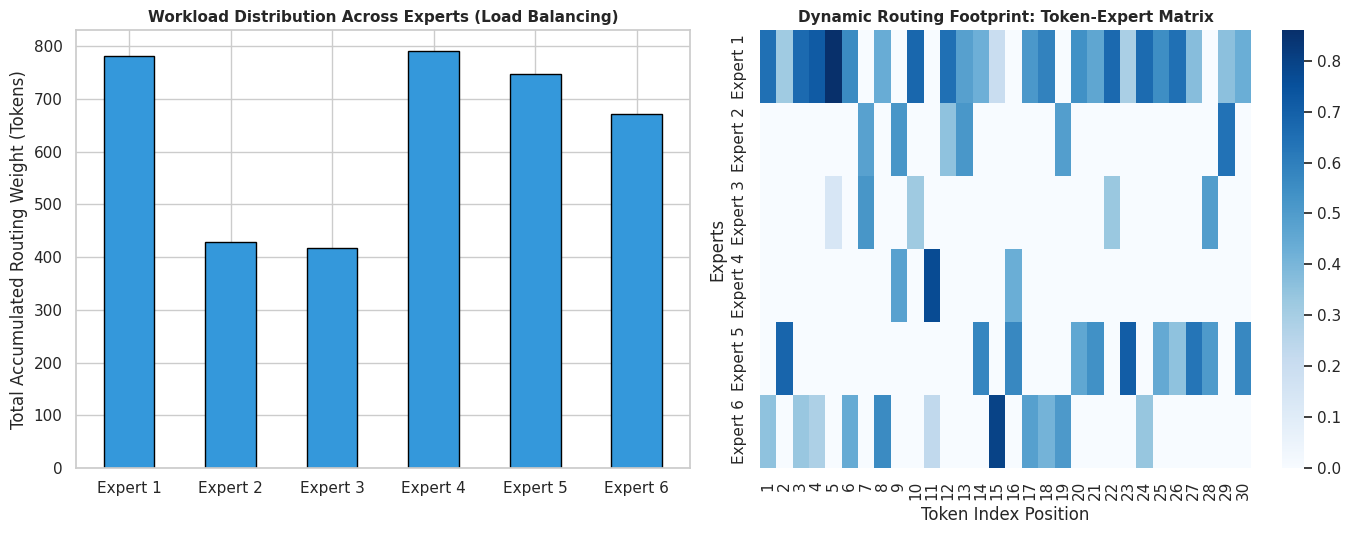

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import tensorflow as tf  # deep learning
from tensorflow import keras  # model engine
from tensorflow.keras import layers  # network layers
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide tf logs
warnings.filterwarnings('ignore')  # silence warnings

SEED = 42  # standard seed
np.random.seed(SEED)  # seed numpy
tf.random.set_seed(SEED)  # seed tensorflow

# ==========================================
# Sparse Mixture of Experts (MoE) Layer
# ==========================================

class MoELayer(layers.Layer):  # custom moe layer
    def __init__(self, num_experts, ff_dim, embed_dim, top_k=2, **kwargs):  # initialization method - MoELayer: Creates routing gate (softmax) and multiple expert networks (each with ReLU hidden + output layer) - activates only top-k experts per token.
        super().__init__(**kwargs)  # parent init
        self.num_experts = num_experts  # total experts count
        self.top_k = top_k  # active experts per token
        self.embed_dim = embed_dim  # input dimensions size
        self.gate = layers.Dense(num_experts, activation='softmax')  # router gating network
        self.experts = [keras.Sequential([  # list of experts
            layers.Dense(ff_dim, activation='relu'),  # expert hidden layer
            layers.Dense(embed_dim)  # expert output projection
        ]) for _ in range(num_experts)]  # end experts pool

    def call(self, inputs):  # feedforward graph method
        gate_probs = self.gate(inputs)  # compute routing weights

        # Select top-k experts dynamically for each token
        top_k_probs, top_k_indices = tf.math.top_k(gate_probs, k=self.top_k)  # fetch top-k attributes
        top_k_probs /= tf.reduce_sum(top_k_probs, axis=-1, keepdims=True)  # re-normalize weights

        # Build routing gating matrix out-of-place to preserve symbolic tensors
        one_hot_indices = tf.one_hot(top_k_indices, depth=self.num_experts)  # convert indices to one-hot
        gating_matrix = tf.reduce_sum(one_hot_indices * tf.expand_dims(top_k_probs, axis=-1), axis=2)  # scale one-hot representations

        # Extract predictions from all experts
        expert_outputs = [expert(inputs) for expert in self.experts]  # run expert forward passes
        stacked_outputs = tf.stack(expert_outputs, axis=2)  # shape: (batch, seq, experts, embed)

        # Perform weighted blend of selected active experts
        final_outputs = tf.reduce_sum(stacked_outputs * tf.expand_dims(gating_matrix, axis=-1), axis=2)  # contract outputs

        return final_outputs, gating_matrix  # return results

# ==========================================
# Transformer Components
# ==========================================

class MoETransformerBlock(layers.Layer):  # custom moe transformer block - MoETransformerBlock: Replaces standard FFN with MoE layer - uses attention first, then routes through sparse experts with residual connections. Returns both output and gating matrix.
    def __init__(self, embed_dim, num_heads, num_experts, ff_dim, top_k=2, **kwargs):  # initialization method
        super().__init__(**kwargs)  # parent init
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)  # multihead attention layer
        self.moe = MoELayer(num_experts, ff_dim, embed_dim, top_k)  # sparse routing moe layer
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)  # norm layer 1
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)  # norm layer 2

    def call(self, inputs):  # feedforward graph method
        attn_output = self.att(inputs, inputs)  # attention output
        out1 = self.layernorm1(inputs + attn_output)  # block 1 residual + norm
        moe_output, gating_matrix = self.moe(out1)  # sparse routing step
        out2 = self.layernorm2(out1 + moe_output)  # block 2 residual + norm
        return out2, gating_matrix  # return variables

class TokenAndPositionEmbedding(layers.Layer):  # combined embedding layer - TokenAndPositionEmbedding: Adds token embeddings + positional embeddings - injects sequence order information for transformer attention.
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):  # initialization method
        super().__init__(**kwargs)  # parent init
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)  # token embedder
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)  # position embedder

    def call(self, x):  # feedforward graph method
        maxlen = tf.shape(x)[-1]  # active sequence length
        positions = tf.range(start=0, limit=maxlen, delta=1)  # generate range index array
        positions = self.pos_emb(positions)  # get position embeddings
        x = self.token_emb(x)  # get token embeddings
        return x + positions  # return combined vectors

# ==========================================
# Build & Compile Model
# ==========================================

def build_moe_model(vocab_size=5000, maxlen=30, embed_dim=16, num_heads=2, num_experts=6, ff_dim=16, top_k=2):  # model factory
    inputs = layers.Input(shape=(maxlen,))  # input sequence node
    embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)  # embedding block
    x = embedding_layer(inputs)  # inject positional representations

    transformer_block = MoETransformerBlock(embed_dim, num_heads, num_experts, ff_dim, top_k)  # moe block
    x, gating_matrix = transformer_block(x)  # pass sequences

    x = layers.GlobalAveragePooling1D()(x)  # pool dimensions
    x = layers.Dropout(0.1)(x)  # regularizing output dropout
    outputs = layers.Dense(2, activation="softmax")(x)  # linear classifier head

    return keras.Model(inputs=inputs, outputs=[outputs, gating_matrix])  # return compiled model

# Compile MoE Transformer Model
model = build_moe_model()  # build architecture instance
model.compile(
    optimizer="adam",
    loss=["sparse_categorical_crossentropy", None],  # optimize only categorical loss
    metrics=[["accuracy"], None]  # map metrics dynamically
)  # end compile

# Generate synthetic text sequences (128 samples, vocab size 5000, max length 30)
x_train = np.random.randint(0, 5000, (128, 30))  # train sequence tokens
y_train = np.random.randint(0, 2, (128,))  # binary classification targets

print("Training Sparse Mixture of Experts Transformer model...")  # status log
history = model.fit(x_train, y_train, epochs=15, batch_size=32, verbose=1)  # train network

# ==========================================
# Evaluate Gating & Experts Workload
# ==========================================

# Run model prediction to inspect token routing assignments
_, gating_outputs = model.predict(x_train, verbose=0)  # extract routing activations

# Calculate how many times each expert was active
expert_workload = np.sum(gating_outputs, axis=(0, 1))  # sum activation probabilities across all tokens

print("\n=====================================")
print("EXPERT WORKLOAD ROUTING SUMMARY")
print("=====================================")
for i, load in enumerate(expert_workload):
    print(f"Expert {i+1} total routed tokens: {load:.2f} ({load/sum(expert_workload)*100:.1f}%)")  # print workload
print("=====================================")

# ==========================================
# Visualizations
# ==========================================

sns.set_theme(style="whitegrid")  # set style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))  # build double canvas

# Left plot: Expert Workload Bar Chart
ax1.bar([f"Expert {i+1}" for i in range(6)], expert_workload, color='#3498db', edgecolor='black', width=0.5)  # draw bars
ax1.set_ylabel('Total Accumulated Routing Weight (Tokens)')
ax1.set_title('Workload Distribution Across Experts (Load Balancing)', fontsize=11, fontweight='bold')

# Right plot: Gating Activation Heatmap for a single sequence sample
sample_idx = 0  # target first sequence sample
sample_gating = gating_outputs[sample_idx]  # shape: (seq_len, num_experts)

sns.heatmap(sample_gating.T, annot=False, cmap='Blues', xticklabels=range(1, 31), yticklabels=[f"Expert {i+1}" for i in range(6)], ax=ax2, cbar=True)  # draw heatmap
ax2.set_xlabel('Token Index Position')
ax2.set_ylabel('Experts')
ax2.set_title('Dynamic Routing Footprint: Token-Expert Matrix', fontsize=11, fontweight='bold')

plt.tight_layout()  # fit layouts
plt.show()  # display plots